In [87]:
import pandas as pd

In [88]:
df_netflix = pd.read_csv('netflix_titles.csv')

In [89]:
df_netflix.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [90]:
df_netflix.shape

(8807, 12)

In [91]:
#rows with missing values
df_netflix[df_netflix.isnull()]
#sum all the rows with missing data
#find the column with the most missing values
df_netflix.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [92]:
#% mean of rows missing in each column
#analyze later whether to delete or drop the column
df_netflix['director'].isnull().mean()

np.float64(0.29908027705234475)

In [93]:
#find the percentage of all null values
for column in df_netflix.columns:
    percentage = df_netflix[column].isnull().mean()
    print(column +" : "+  str(round(percentage * 100, 2)))

show_id : 0.0
type : 0.0
title : 0.0
director : 29.91
cast : 9.37
country : 9.44
date_added : 0.11
release_year : 0.0
rating : 0.05
duration : 0.03
listed_in : 0.0
description : 0.0


In [94]:
#Handling the missing data
#dropping the whole column
df_netflix.drop("director", axis=1)

#drop row #better approach
no_director= df_netflix[df_netflix['director'].isnull()].index
df_netflix.drop(no_director, axis=0, inplace = True)

#df_netflix[~(df_netflix['director'].isnull())]


In [95]:
#replace the missing data with the mean, median or mode
rating_mode = df_netflix["rating"].mode()[0]
df_netflix["rating"] = df_netflix["rating"].fillna(rating_mode)

In [96]:
df_netflix[df_netflix["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


In [97]:
df_netflix['rating']

0       PG-13
2       TV-MA
5       TV-MA
6          PG
7       TV-MA
        ...  
8801    TV-MA
8802        R
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 6173, dtype: str

In [98]:
#data extraction
df_netflix['duration']

0         90 min
2       1 Season
5       1 Season
6         91 min
7        125 min
          ...   
8801      96 min
8802     158 min
8804      88 min
8805      88 min
8806     111 min
Name: duration, Length: 6173, dtype: str

In [99]:
df_movie = df_netflix[df_netflix['type'] == 'Movie']

In [100]:
df_movie["duration"].str.split()

0        [90, min]
6        [91, min]
7       [125, min]
9       [104, min]
12      [127, min]
           ...    
8801     [96, min]
8802    [158, min]
8804     [88, min]
8805     [88, min]
8806    [111, min]
Name: duration, Length: 5943, dtype: object

In [101]:
df_movie["duration_num"]= (df_movie['duration']
    .str
    .split()
    .str[0]
    .fillna(0)
    .astype(int)
)

In [106]:
df_movie['minute']=df_movie["duration_num"]

In [110]:
df_movie['date_added'].str.split(',', expand = True)[1]
#df_movie['date_added'].str.extract('(\d{4})')

0        2021
6        2021
7        2021
9        2021
12       2021
        ...  
8801     2016
8802     2019
8804     2019
8805     2020
8806     2019
Name: 1, Length: 5943, dtype: str

In [112]:
import matplotlib.pyplot as plt

<Axes: ylabel='Frequency'>

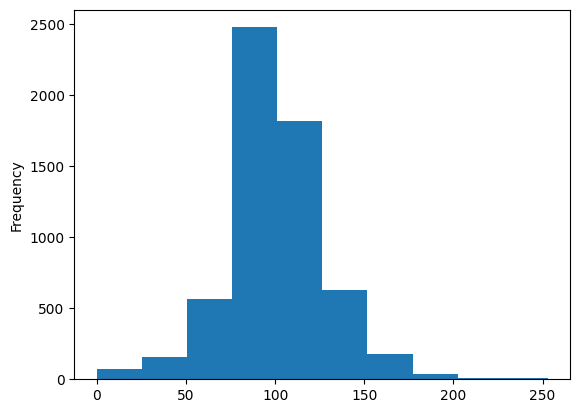

In [113]:
#identification of outliers
df_movie["minute"].plot(kind ='hist', bins = 10)

In [114]:
df_movie['minute'].value_counts(bins=10).sort_index()

(-0.254, 25.3]      72
(25.3, 50.6]       157
(50.6, 75.9]       567
(75.9, 101.2]     2475
(101.2, 126.5]    1813
(126.5, 151.8]     631
(151.8, 177.1]     178
(177.1, 202.4]      34
(202.4, 227.7]      10
(227.7, 253.0]       6
Name: count, dtype: int64

In [115]:
df_movie[(df_movie['minute']>25) & (df_movie['minute']< 227)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_num,minute
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125,125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,96,96
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158,158
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88,88
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88,88


<Axes: xlabel='rating'>

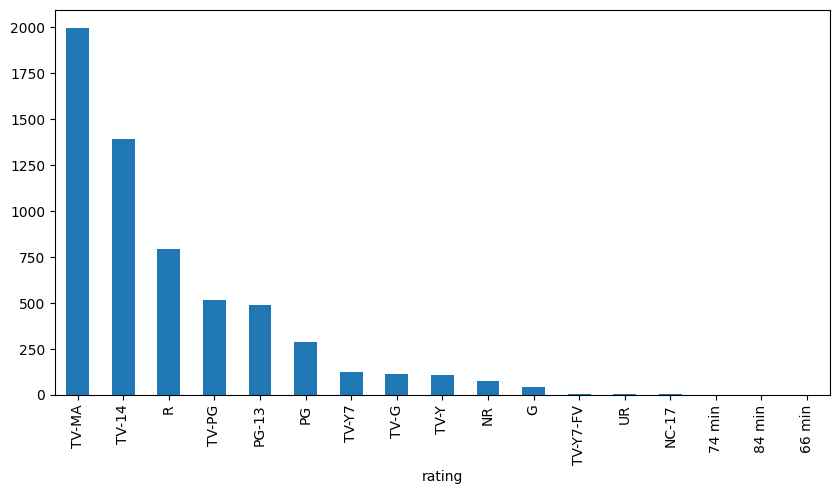

In [117]:
#outliers using categorical data
df_movie['rating'].value_counts().plot(kind = 'bar', figsize = (10,5))
##alternative using the 

In [ ]:
#normalisation
#handling inconsistent capitalisation
df_movie['title']= df_movie['title'].str.title()

In [123]:
#removing blank spaces
df_movie['title']= df_movie['title'].str.strip()

In [125]:
df_movie['title'].replace('[^\w\s]', '', regex=True)

0                  Dick Johnson Is Dead
6       My Little Pony A New Generation
7                               Sankofa
9                          The Starling
12                         Je Suis Karl
                     ...               
8801                            Zinzana
8802                             Zodiac
8804                         Zombieland
8805                               Zoom
8806                             Zubaan
Name: title, Length: 5943, dtype: str